In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import accuracy_score
from IPython.display import display, Image, clear_output 

# PyTorch
import torch
from torch.utils import data
import torch.nn as nn
from torch.nn.functional import mse_loss, l1_loss, cross_entropy
from torch import optim

# 30760 plotting routines
import utility_30760 as util


# MNIST classification with a convolutional network

1. Load data
- Implement dataloader
- Design network
- Design error/loss function
- Train and validate the network
- Evaluate performance

## Load data

In [2]:
# Load a subset of the full MNIST dataset
N_mnist = 2000

mnist = np.load('mnist.npz')
num_classes = 10
dim = 28
x_mnist = mnist['X_train'][:N_mnist].astype('float32')
labels_mnist = mnist['y_train'][:N_mnist].astype('int32')

print("x_mnist:\t", x_mnist.shape)
print("labels_mnist:\t", labels_mnist.shape)

x_mnist:	 (2000, 784)
labels_mnist:	 (2000,)


### Change input shape

In [3]:
class Dataset(data.Dataset):
    "Characterizes a dataset for PyTorch"
    def __init__(self, list_IDs, labels, x, dim):
            'Initialization'
            self.list_IDs = list_IDs
            self.labels = labels
            self.x = x
            self.dim = dim
            
    def __len__(self):
            'Denotes the total number of samples'
            return len(self.list_IDs)

    def __getitem__(self, index):
            'Generates one sample of data'
            # Select sample
            ID = self.list_IDs[index]

            # Load data and get label
            #x = torch.from_numpy(self.x[ID,:]).float()
            x = torch.from_numpy(self.x[ID,:].reshape((1, self.dim, self.dim))).float()
            
            y = self.labels[ID]

            return x, y

In [4]:
split_frac = 0.75
batch_size = 100

# data ID
labels_ID = np.arange(0,len(labels_mnist))
labels_tuple = zip(labels_ID, labels_mnist)

# Partition IDs
idx_split_data = int(split_frac*N_mnist)
partition = {"train": labels_ID[:idx_split_data], "validation": labels_ID[idx_split_data:]} # IDs
labels = {ID: label for (ID, label) in labels_tuple} # Labels

# Parameters
DL_params = {'batch_size': batch_size, 'shuffle': True}

# Generators
training_set = Dataset(partition['train'], labels, x_mnist, dim)
training_generator = data.DataLoader(training_set, **DL_params)

validation_set = Dataset(partition['validation'], labels, x_mnist, dim)
validation_generator = data.DataLoader(validation_set, **DL_params)

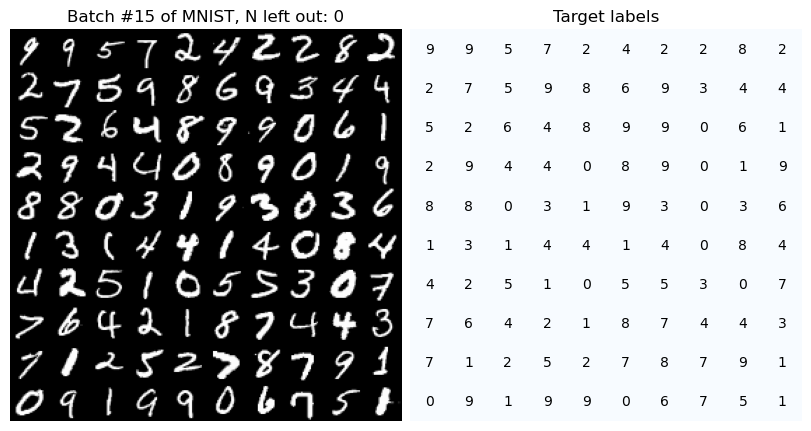

In [5]:
count = 1
fig = plt.figure(figsize=(8,8), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 2) # Add 1x2 grid
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 

# WALK THROUGH TRAINING SET
for x_train, y_train in training_generator:
    
    # Initiation parameters
    canvas_size = int(np.sqrt(x_train.shape[0]))
    ax2.clear()
    ax2.set_title("Target labels")
    ax2.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Blues)
    canvas = np.zeros((dim*canvas_size, canvas_size*dim))
    batch_left_out = x_train.shape[0] - canvas_size**2
    idx = 0  
    
    # WALK THROUGH EACH BATCH
    for i in range(canvas_size):
        for j in range(canvas_size):
            
            canvas[i*dim:(i+1)*dim, j*dim:(j+1)*dim] = x_train[idx]#.reshape((dim, dim)) 
            ax2.text(j, i, str(y_train.detach().numpy()[idx]), va='center', ha='center')
            idx += 1     
            
    # Finalize plots
    ax1.clear()
    ax1.set_title("Batch #{} of MNIST, N left out: {}".format(count,batch_left_out))
    ax1.imshow(canvas, cmap='gray')
    ax1.axis('off')
    ax2.axis('off')
    #fig.canvas.draw()
    display(fig)
    clear_output(wait=True)
    count += 1
    # Pause between each iteration
    time.sleep(0.0)

## Design convolutional network


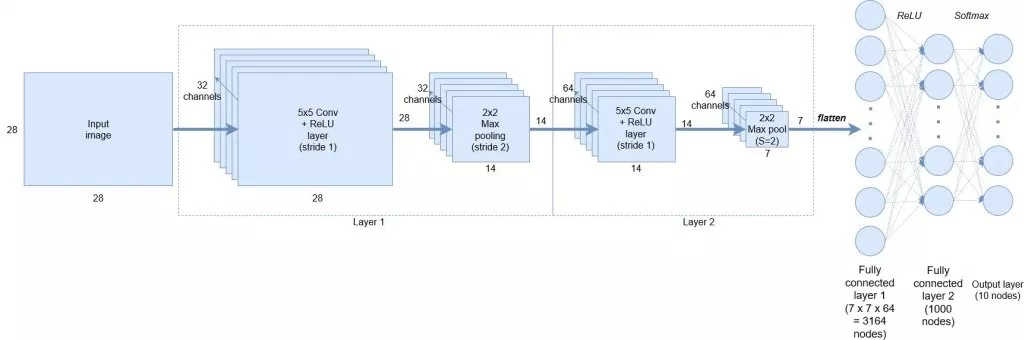

In [6]:
Image(filename='CNN-example-block-diagram.jpg') 

In [7]:
class simpleCN(nn.Module):
    def __init__(self, layer_1, layer_2, layer_3):
        super(simpleCN, self).__init__()
        
        # Store the input network
        self.layer_1 = layer_1
        self.layer_2 = layer_2
        self.layer_3 = layer_3

    def forward(self, x): 
        outputs = {}

        # Forward propagate input through the network
        out = self.layer_1(x)
        out = self.layer_2(out)
        out = out.reshape(out.size(0), -1) # Flatten output to [batch_size, linear layer 1 units]
        y = self.layer_3(out)
        
        return y

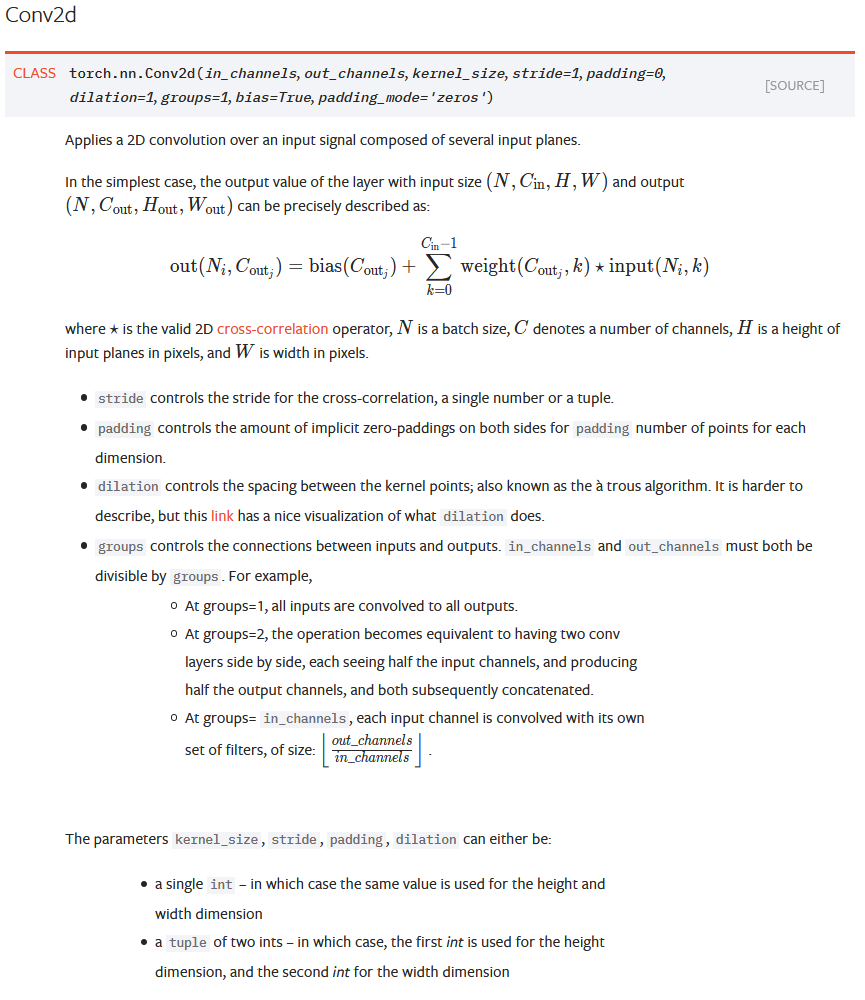

In [8]:
Image(filename='pytorch_conv2d_docs.png') 

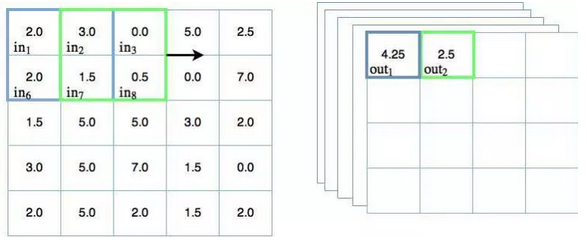

In [9]:
Image(filename='conv2d_filters_tutorial.png') 

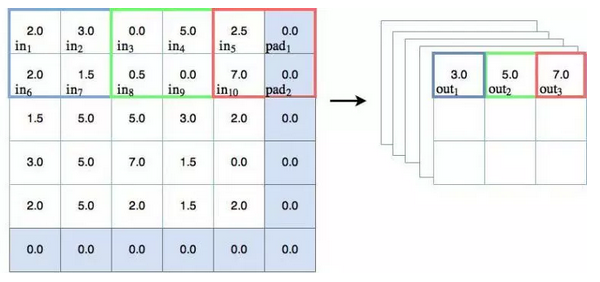

In [10]:
Image(filename='pooling_tutorial.png') 

__What is the width and height of my output?__

$ W_{out} = \frac{W_{in}-F_W+2P_W}{S_W} + 1 $

$ H_{out} = \frac{H_{in}-F_H+2P_H}{S_H} + 1 $

F is the filter size, P is the padding, and S is the stride. These values are directionally dependant.

_Balance these equations depending on the design you want_

Mostly you have an idea of output size, filter size, and stride. You can then find the needed padding with:

$ P_W = \frac{W_{out}S_W - W_{in} + F_W - S_W}{2}$

$ P_H = \frac{H_{out}S_H - H_{in} + F_H - S_H}{2}$

Note that Pytorch only accepts padding less than half of kernel size.

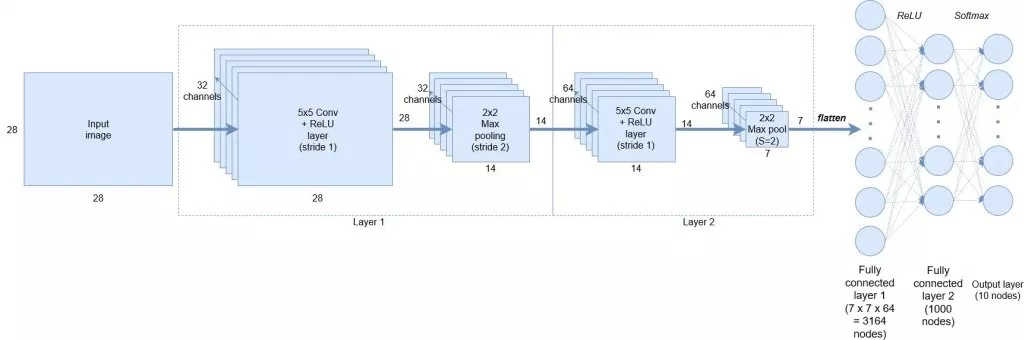

In [11]:
Image(filename='CNN-example-block-diagram.jpg') 

In [12]:
# SMALL CONV NETWORK

layer_1 = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        )

layer_2 = nn.Sequential(
            nn.Conv2d(10, 20, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

layer_3 = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(3 * 3 * 20, 50),
            nn.Linear(50, 10),
        )

net = simpleCN(layer_1, layer_2, layer_3)

# Net size
net_N_param = sum([p.numel() for p in net.parameters()])
print("Trainable parameters: ", net_N_param)

# Transfer model to GPU if available
cuda_available = torch.cuda.is_available()
#cuda_available = False # Force CPU
if cuda_available:
    device = torch.device("cuda:0" if cuda_available else "cpu")
    print("Transferring net to single available GPU:", device)

    net = net.to(device)

print(net)

Trainable parameters:  11550
simpleCN(
  (layer_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer_2): Sequential(
    (0): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_3): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=180, out_features=50, bias=True)
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)


## Design error/loss function

In [13]:
def error_func_mnist(y_out, y_t):
    
    E = cross_entropy(y_out, y_t.long(), reduction = "mean")
    
    return E

## Train and validate the network

Final training accuracy:	 78.0
Final validation accuracy:	 96.0
Run time: 108.766s


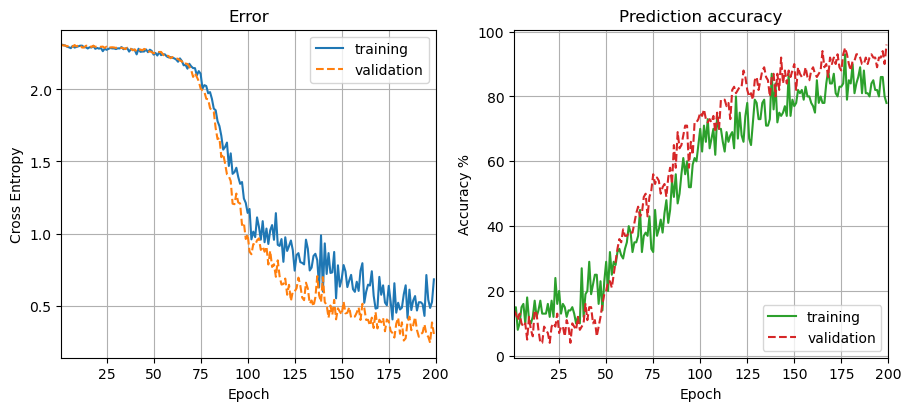

In [14]:
optimizer = optim.SGD(net.parameters(), lr=0.01, weight_decay = 0.01)

N_epochs = 200

fig = plt.figure(figsize=(9,4), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 2) # Add 1x2 grid
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 

E_train_collect, E_valid_collect = [], []

acc_train_collect, acc_valid_collect = [],[]

t0 = time.time()

# Iterate over epochs
for epoch in np.arange(1,N_epochs):
    net.train() # Set network in "training mode"

    # Go through each batch in the training dataset using the loader
    for x_train, y_train in training_generator:

        if cuda_available:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
        
        y_out_train = net(x_train) # Forward propagate through the network

        E_train = error_func_mnist(y_out_train, y_train) # Estimate error

        optimizer.zero_grad() # Reset gradients to zero
        E_train.backward() # Back-propagate to get the gradients based on the estimated error
        optimizer.step() # Update through the optimizer (e.g. stochastic gradient descent)
        
    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval() # Set network in "evaluation mode"

        # Just load a single validation batch from the test loader
        x_valid, y_valid = next(iter(validation_generator))

        if cuda_available:
            x_valid = x_valid.to(device)
            y_valid = y_valid.to(device)
        
        y_out_valid = net(x_valid) # Forward propagate the validation set

        E_valid = error_func_mnist(y_out_valid, y_valid) # Compute the validation error

    
    
    E_train_collect.append(E_train.sum().detach().cpu().numpy())
    E_valid_collect.append(E_valid.sum().detach().cpu().numpy())
    # Accuracy
    acc_train  = accuracy_score(y_train.detach().cpu().numpy(), np.argmax(y_out_train.detach().cpu().numpy(),axis=1))
    acc_train_collect.append(acc_train*100)
    acc_valid  = accuracy_score(y_valid.detach().cpu().numpy(), np.argmax(y_out_valid.detach().cpu().numpy(),axis=1))
    acc_valid_collect.append(acc_valid*100)
    
    # Finalize plots   
    ax1.clear()
    ax2.clear()
    ax1.set_title('Error')
    ax2.set_title('Prediction accuracy')
    ax1.set_xlabel("Epoch")
    ax2.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy")
    ax2.set_ylabel("Accuracy %")
    ax2.set_xlim([1,N_epochs])
    ax1.set_xlim([1,N_epochs])
    ax1.grid()
    ax2.grid()
    ax1.plot(np.arange(1,epoch+1), E_train_collect, '-', color="C0", label = "training")
    ax1.plot(np.arange(1,epoch+1), E_valid_collect, '--', color="C1", label = "validation")
    ax2.plot(np.arange(1,epoch+1), acc_train_collect, '-', color="C2", label = "training")
    ax2.plot(np.arange(1,epoch+1), acc_valid_collect, '--', color="C3", label = "validation")
    ax1.legend(loc="upper right")
    ax2.legend(loc="lower right")
    display(fig)
    clear_output(wait=True)
    
print("Final training accuracy:\t", acc_train_collect[-1])
print("Final validation accuracy:\t", acc_valid_collect[-1])

t1 = time.time()
time_take = (t1-t0)
run_time = 'Run time: {:.3f}s'.format(time_take)
print(run_time)

## Evaluate performance

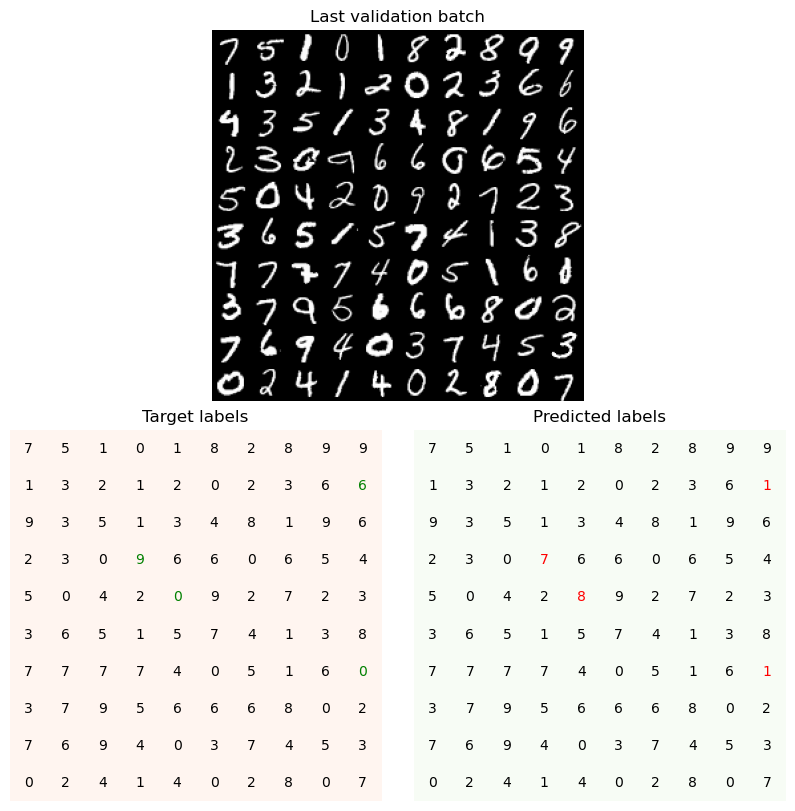

In [15]:
count = 1
canvas_size = int(np.sqrt(x_valid.shape[0]))
fig = plt.figure(figsize=(8,8), constrained_layout=True) # Initiate figure with constrained layout
gs = fig.add_gridspec(2, 2) # Add 2x2 grid
ax1 = fig.add_subplot(gs[0, :]) 
ax2 = fig.add_subplot(gs[1, 0]) 
ax3 = fig.add_subplot(gs[1, 1])

# Initiation parameters
ax2.clear()
ax2.set_title("Target labels")
ax2.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Reds)
ax3.clear()
ax3.set_title("Predicted labels")
ax3.imshow(np.zeros((canvas_size, canvas_size)), cmap=plt.cm.Greens)
canvas = np.zeros((dim*canvas_size, canvas_size*dim))
batch_left_out = x_train.shape[0] - canvas_size**2
idx = 0 

pred_difference = np.argmax(y_out_valid.detach().cpu().numpy(),axis=1) - y_valid.detach().cpu().numpy()

# WALK THROUGH EACH BATCH
for i in range(canvas_size):
    for j in range(canvas_size):

        canvas[i*dim:(i+1)*dim, j*dim:(j+1)*dim] = x_valid.cpu()[idx]#.reshape((dim, dim)) 
        
        if pred_difference[idx] == 0:
            text_color_str_t = "black"
            text_color_str_p = "black"
        else:
            text_color_str_t = "green"
            text_color_str_p = "red"
        
        #print(pred_difference[idx])
        ax3.text(j, i, str(np.argmax(y_out_valid.detach().cpu().numpy(),axis=1)[idx]), va='center', ha='center', color = text_color_str_p)
        ax2.text(j, i, str(y_valid.detach().cpu().numpy()[idx]), va='center', ha='center', color = text_color_str_t)
        idx += 1     

# Finalize plots
ax1.clear()
ax1.set_title("Last validation batch")
ax1.imshow(canvas, cmap='gray')
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
#fig.canvas.draw()
display(fig)
clear_output(wait=True)

## Exercise

1. Implement the network shown in the example block diagram. 
2. Make other changes to the network to improve prediction accuracy. Feel free to change the network structure too. Keep the same MNIST dataset size, batch size, and training/validation fraction.

### Suggestions for changes to the network

__Error function changes__

Sum reduction

```Python
E = cross_entropy(_, _, reduction = "sum")
```

__Parameter changes__

Number of epochs

```Python
N_epochs = 200
```

Learning rate

```Python
optimizer = optim.SGD(net.parameters(), lr=0.001)
```

__Different optimizers__

E.g. the Adam optimization algorithm ([Adam paper](https://arxiv.org/pdf/1412.6980.pdf))

```Python
optimizer = optim.Adam(net.parameters(), lr=0.001)
```
Find more here: https://pytorch.org/docs/stable/optim.html